In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

df = yf.download("AAPL", start="2020-12-31", end="2026-01-01")
df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [2]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-12-31,129.046677,131.040392,128.103309,130.398510,99116600
2021-01-04,125.856705,129.941379,123.279466,129.853854,143301900
2021-01-05,127.412743,128.122709,124.903582,125.350958,97664900
2021-01-06,123.123856,127.451673,122.909895,124.213106,155088000
2021-01-07,127.325226,128.015737,124.349249,124.835520,109578200
...,...,...,...,...,...
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200


In [3]:
df['Returns(%)'] = df['Close'].pct_change()
df['Returns(%)'] = df['Returns(%)'] * 100

In [4]:
df = df[['Close','Returns(%)']]

In [5]:
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df

C:\Users\yashr\AppData\Local\Temp\ipykernel_10848\3739716951.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA20'] = df['Close'].rolling(20).mean()
C:\Users\yashr\AppData\Local\Temp\ipykernel_10848\3739716951.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA50'] = df['Close'].rolling(50).mean()


Price,Close,Returns(%),MA20,MA50
Date,,,,
2020-12-31,129.046677,NaN,NaN,NaN
2021-01-04,125.856705,-2.471952,NaN,NaN
2021-01-05,127.412743,1.236357,NaN,NaN
2021-01-06,123.123856,-3.366137,NaN,NaN
2021-01-07,127.325226,3.412312,NaN,NaN
...,...,...,...,...
2025-12-24,273.554016,0.532382,276.892905,270.701263
2025-12-26,273.144409,-0.149735,276.685599,271.186837
2025-12-29,273.504089,0.131681,276.431337,271.717334


In [6]:
df['Previous_Close'] = df['Close'].shift(1)
df

C:\Users\yashr\AppData\Local\Temp\ipykernel_10848\3339221216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Previous_Close'] = df['Close'].shift(1)


Price,Close,Returns(%),MA20,MA50,Previous_Close
Date,,,,,
2020-12-31,129.046677,NaN,NaN,NaN,NaN
2021-01-04,125.856705,-2.471952,NaN,NaN,129.046677
2021-01-05,127.412743,1.236357,NaN,NaN,125.856705
2021-01-06,123.123856,-3.366137,NaN,NaN,127.412743
2021-01-07,127.325226,3.412312,NaN,NaN,123.123856
...,...,...,...,...,...
2025-12-24,273.554016,0.532382,276.892905,270.701263,272.105377
2025-12-26,273.144409,-0.149735,276.685599,271.186837,273.554016
2025-12-29,273.504089,0.131681,276.431337,271.717334,273.144409


In [7]:
df_monthly = df.resample("M").last()
df_monthly.drop(columns='Returns(%)',inplace=True)
df_monthly['Monthly_Returns(%)'] = df_monthly['Close'].pct_change()
df_monthly['Monthly_Returns(%)'] = df_monthly['Monthly_Returns(%)']*100
df_monthly

C:\Users\yashr\AppData\Local\Temp\ipykernel_10848\1449841892.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").last()


Price,Close,MA20,MA50,Previous_Close,Monthly_Returns(%)
Date,,,,,
2020-12-31,129.046677,NaN,NaN,NaN,NaN
2021-01-31,128.336655,129.367089,NaN,133.325806,-0.550206
2021-02-28,118.106705,128.083172,NaN,117.843742,-7.971183
2021-03-31,118.973557,118.246468,124.765802,116.782074,0.733956
2021-04-30,128.041443,128.814321,123.121609,130.008926,7.621766
...,...,...,...,...,...
2025-08-31,231.698380,225.270542,214.971646,232.117584,11.963896
2025-09-30,254.145599,242.661979,229.653551,253.945969,9.688121
2025-10-31,269.855652,258.017712,247.776133,270.883667,6.181517


In [8]:
df['Returns(%)'].agg(['mean','std'])

mean    0.074646
std     1.755956
Name: Returns(%), dtype: float64

In [9]:
max = df['Returns(%)'].idxmax()
df.loc[max]


Price
Close             197.987091
Returns(%)         15.328849
MA20              210.021640
MA50              225.234321
Previous_Close    171.671783
Name: 2025-04-09 00:00:00, dtype: float64

In [10]:
min = df['Returns(%)'].idxmin()
df.loc[min]

Price
Close             202.308243
Returns(%)         -9.245617
MA20              218.149216
MA50              228.668265
Previous_Close    222.918427
Name: 2025-04-03 00:00:00, dtype: float64

In [11]:
max = df_monthly['Monthly_Returns(%)'].idxmax()
df_monthly.loc[max]

Price
Close                 159.458694
MA20                  146.860297
MA50                  141.515866
Previous_Close        154.395630
Monthly_Returns(%)     18.863322
Name: 2022-07-31 00:00:00, dtype: float64

In [12]:
min = df_monthly['Monthly_Returns(%)'].idxmin()
df_monthly.loc[min]

Price
Close                 127.879303
MA20                  135.187130
MA50                  140.764692
Previous_Close        127.564369
Monthly_Returns(%)    -12.227273
Name: 2022-12-31 00:00:00, dtype: float64

Text(0.5, 1.0, 'Apple Stock Prices')

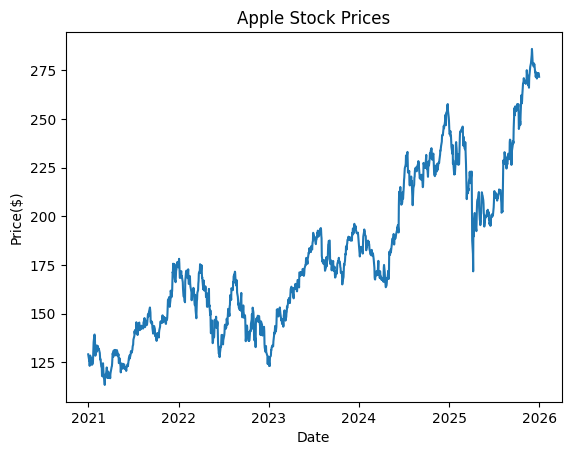

In [13]:
plt.plot(df['Close'])
plt.xlabel('Date')
plt.ylabel('Price($)')
plt.title('Apple Stock Prices')

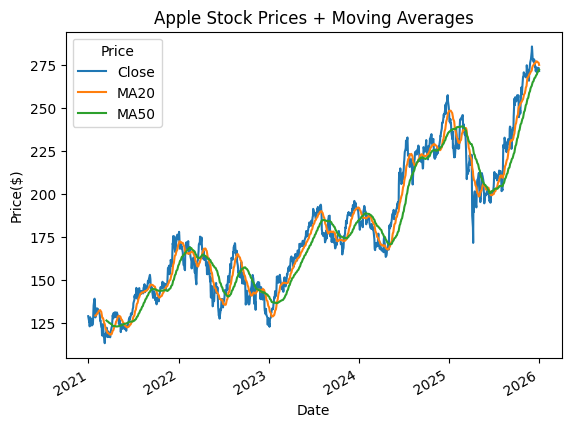

In [14]:
df[['Close','MA20','MA50']].plot()

plt.xlabel('Date')
plt.ylabel('Price($)')
plt.title('Apple Stock Prices + Moving Averages')
plt.show()


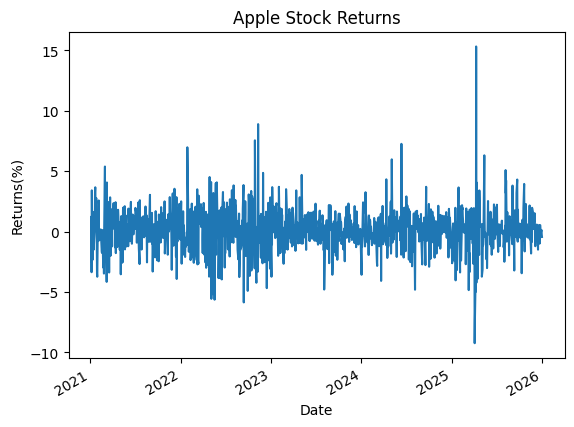

In [15]:
df['Returns(%)'].plot()

plt.xlabel('Date')
plt.ylabel('Returns(%)')
plt.title('Apple Stock Returns')
plt.show()